In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product, combinations

# Complex I

- https://www.rcsb.org/structure/9I4I

In [2]:
def compute_contact_map(coords, threshold=8.0):
    """Compute contact map from C-alpha coordinates."""
    diff = coords[:, None, :] - coords[None, :, :]
    distances = np.sqrt((diff ** 2).sum(axis=-1))
    contacts = (distances < threshold).astype(float)
    np.fill_diagonal(contacts, 0)
    return contacts, distances

In [3]:
def parse_cif_ca(cif_path):
    """Extract C-alpha coordinates from mmCIF file, organized by chain."""
    chains = {}
    in_atom_site = False
    headers = []    
    with open(cif_path) as f:
        for line in f:
            line = line.strip()
            # Detect start of atom_site loop
            if line == "loop_":
                in_atom_site = False
                headers = []
            elif line.startswith("_atom_site."):
                in_atom_site = True
                headers.append(line.split(".")[1])
            elif in_atom_site and not line.startswith("_") and line and not line.startswith("#"):
                # Parse atom record
                parts = line.split()
                if len(parts) < len(headers):
                    continue
                record = dict(zip(headers, parts))
                # Only C-alpha atoms
                if record.get("label_atom_id") != "CA":
                    continue
                if record.get("group_PDB") != "ATOM":
                    continue
                chain_id = record.get("auth_asym_id", record.get("label_asym_id"))
                x = float(record.get("Cartn_x", 0))
                y = float(record.get("Cartn_y", 0))
                z = float(record.get("Cartn_z", 0))
                res_num = int(record.get("auth_seq_id", record.get("label_seq_id", 0)))
                res_name = record.get("label_comp_id", "UNK")
                if chain_id not in chains:
                    chains[chain_id] = {"coords": [], "residues": [], "res_names": []}
                chains[chain_id]["coords"].append([x, y, z])
                chains[chain_id]["residues"].append(res_num)
                chains[chain_id]["res_names"].append(res_name)
            elif in_atom_site and (line.startswith("#") or line.startswith("_")):
                in_atom_site = False    
    # Convert to numpy arrays
    for chain_id in chains:
        chains[chain_id]["coords"] = np.array(chains[chain_id]["coords"])
    return chains

In [4]:
# Load Complex I structure
CIF_PATH = "9I4I.cif"
chains = parse_cif_ca(CIF_PATH)

print(f"Parsed {len(chains)} chains from {CIF_PATH}\n")

# Check for gaps in residue numbering
print("Chain residue coverage (gaps indicate unresolved regions):\n")
for chain_id, data in sorted(chains.items(), key=lambda x: len(x[1]["coords"]), reverse=True)[:15]:
    res_nums = data["residues"]
    min_res, max_res = min(res_nums), max(res_nums)
    expected = max_res - min_res + 1
    actual = len(res_nums)
    missing = expected - actual
    
    # Find gaps
    gaps = []
    sorted_res = sorted(res_nums)
    for i in range(len(sorted_res) - 1):
        if sorted_res[i+1] - sorted_res[i] > 1:
            gaps.append(f"{sorted_res[i]+1}-{sorted_res[i+1]-1}")
    
    gap_str = f"  gaps: {', '.join(gaps[:3])}{'...' if len(gaps) > 3 else ''}" if gaps else ""
    print(f"  Chain {chain_id:>2}: res {min_res:>3}-{max_res:<4} ({actual:>3} modeled, {missing:>3} missing){gap_str}")

Parsed 45 chains from 9I4I.cif

Chain residue coverage (gaps indicate unresolved regions):

  Chain  M: res  30-716  (687 modeled,   0 missing)
  Chain  l: res   3-603  (601 modeled,   0 missing)
  Chain  r: res   1-459  (459 modeled,   0 missing)
  Chain  C: res  27-460  (434 modeled,   0 missing)
  Chain  Q: res  34-463  (429 modeled,   1 missing)  gaps: 118-118
  Chain  i: res   1-347  (347 modeled,   0 missing)
  Chain  J: res  36-376  (341 modeled,   0 missing)
  Chain  w: res  36-355  (320 modeled,   0 missing)
  Chain  s: res   3-318  (316 modeled,   0 missing)
  Chain  O: res  36-247  (212 modeled,   0 missing)
  Chain  P: res  43-250  (208 modeled,   0 missing)
  Chain  D: res  35-210  (176 modeled,   0 missing)
  Chain  m: res   1-173  (173 modeled,   0 missing)
  Chain  p: res   7-179  (173 modeled,   0 missing)
  Chain  u: res   2-172  (171 modeled,   0 missing)


In [5]:
# Parse UniProt references from CIF file
def parse_cif_uniprot(cif_path):
    """Extract chain -> UniProt mapping from CIF _struct_ref sections."""
    # First pass: get accession -> entry_name from _struct_ref
    accession_to_entry = {}
    # Second pass: get chain -> accession from _struct_ref_seq
    chain_to_accession = {}
    with open(cif_path) as f:
        content = f.read()
    # Parse _struct_ref for accession -> entry_name
    for line in content.split('\n'):
        if ' UNP ' in line:
            parts = line.split()
            # Format: entity_id UNP entry_name accession ...
            if len(parts) >= 4:
                entry_name = parts[2]  # e.g., NDUS2_HUMAN
                accession = parts[3]   # e.g., O75306
                accession_to_entry[accession] = entry_name
    # Parse _struct_ref_seq for chain -> accession
    for line in content.split('\n'):
        parts = line.split()
        # Format: align_id ref_id pdb_code strand_id ... accession
        if len(parts) >= 9 and parts[2] == '9I4I':
            chain_id = parts[3]
            accession = parts[8]
            chain_to_accession[chain_id] = accession
    # Combine: chain -> (accession, entry_name)
    chain_to_uniprot = {}
    for chain_id, accession in chain_to_accession.items():
        entry_name = accession_to_entry.get(accession, "")
        chain_to_uniprot[chain_id] = {
            "uniprot_accession": accession,
            "uniprot_entry": entry_name,
        }
    return chain_to_uniprot

# Parse UniProt info from CIF
uniprot_info = parse_cif_uniprot(CIF_PATH)

# Map UniProt entry names to standard gene symbols
ENTRY_TO_GENE = {
    # mtDNA-encoded
    "NU1M_HUMAN": "MT-ND1", "NU2M_HUMAN": "MT-ND2", "NU3M_HUMAN": "MT-ND3",
    "NU4M_HUMAN": "MT-ND4", "NU4LM_HUMAN": "MT-ND4L", "NU5M_HUMAN": "MT-ND5",
    "NU6M_HUMAN": "MT-ND6",
    # Nuclear - NDUFS (iron-sulfur)
    "NDUS1_HUMAN": "NDUFS1", "NDUS2_HUMAN": "NDUFS2", "NDUS3_HUMAN": "NDUFS3",
    "NDUS4_HUMAN": "NDUFS4", "NDUS5_HUMAN": "NDUFS5", "NDUS6_HUMAN": "NDUFS6",
    "NDUS7_HUMAN": "NDUFS7", "NDUS8_HUMAN": "NDUFS8",
    # Nuclear - NDUFV (flavoprotein)
    "NDUV1_HUMAN": "NDUFV1", "NDUV2_HUMAN": "NDUFV2", "NDUV3_HUMAN": "NDUFV3",
    # Nuclear - NDUFA (alpha subcomplex)
    "NDUA1_HUMAN": "NDUFA1", "NDUA2_HUMAN": "NDUFA2", "NDUA3_HUMAN": "NDUFA3",
    "NDUA5_HUMAN": "NDUFA5", "NDUA6_HUMAN": "NDUFA6", "NDUA7_HUMAN": "NDUFA7",
    "NDUA8_HUMAN": "NDUFA8", "NDUA9_HUMAN": "NDUFA9", "NDUAA_HUMAN": "NDUFA10",
    "NDUAB_HUMAN": "NDUFA11", "NDUAC_HUMAN": "NDUFA12", "NDUAD_HUMAN": "NDUFA13",
    # Nuclear - NDUFB (beta subcomplex)
    "NDUB1_HUMAN": "NDUFB1", "NDUB2_HUMAN": "NDUFB2", "NDUB3_HUMAN": "NDUFB3",
    "NDUB4_HUMAN": "NDUFB4", "NDUB5_HUMAN": "NDUFB5", "NDUB6_HUMAN": "NDUFB6",
    "NDUB7_HUMAN": "NDUFB7", "NDUB8_HUMAN": "NDUFB8", "NDUB9_HUMAN": "NDUFB9",
    "NDUBA_HUMAN": "NDUFB10", "NDUBB_HUMAN": "NDUFB11",
    # Nuclear - NDUFC
    "NDUC1_HUMAN": "NDUFC1", "NDUC2_HUMAN": "NDUFC2",
    # Nuclear - Other
    "ACPM_HUMAN": "NDUFAB1",
}

# Build SUBUNITS dict with UniProt info
SUBUNITS = {}
for chain_id, up_info in uniprot_info.items():
    entry_name = up_info["uniprot_entry"]
    gene = ENTRY_TO_GENE.get(entry_name, entry_name)
    
    # Determine origin from gene name pattern
    origin = "mtDNA" if gene.startswith("MT-") else "nuclear"
    
    SUBUNITS[chain_id] = {
        "gene": gene,
        "origin": origin,
        "uniprot_accession": up_info["uniprot_accession"],
        "uniprot_entry": entry_name,
    }

# Match to available chains
matched_subunits = {k: v for k, v in SUBUNITS.items() if k in chains}

# Summary by origin
mtdna_count = sum(1 for v in matched_subunits.values() if v["origin"] == "mtDNA")
nuclear_count = sum(1 for v in matched_subunits.values() if v["origin"] == "nuclear")

print(f"Parsed {len(uniprot_info)} UniProt references from CIF")
print(f"Matched {len(matched_subunits)} subunits to structure chains:")
print(f"  - mtDNA-encoded:    {mtdna_count}")
print(f"  - Nuclear-encoded:  {nuclear_count}")
print(f"\nSubunits by origin:\n")

for origin in ["mtDNA", "nuclear"]:
    print(f"  {origin.upper()}:")
    for chain_id, info in sorted(matched_subunits.items(), key=lambda x: x[1]["gene"]):
        if info["origin"] == origin:
            n_res = len(chains[chain_id]["coords"])
            print(f"    Chain {chain_id:>2}: {info['gene']:>10} ({info['uniprot_accession']}) - {n_res:>3} residues")

Parsed 45 UniProt references from CIF
Matched 45 subunits to structure chains:
  - mtDNA-encoded:    7
  - Nuclear-encoded:  38

Subunits by origin:

  MTDNA:
    Chain  s:     MT-ND1 (P03886) - 316 residues
    Chain  i:     MT-ND2 (P03891) - 347 residues
    Chain  j:     MT-ND3 (P03897) - 115 residues
    Chain  r:     MT-ND4 (P03905) - 459 residues
    Chain  k:    MT-ND4L (P03901) -  98 residues
    Chain  l:     MT-ND5 (P03915) - 601 residues
    Chain  m:     MT-ND6 (P03923) - 173 residues
  NUCLEAR:
    Chain  S:     NDUFA1 (O15239) -  70 residues
    Chain  w:    NDUFA10 (O95299) - 320 residues
    Chain  V:    NDUFA11 (Q86Y39) - 140 residues
    Chain  N:    NDUFA12 (Q9UI09) - 144 residues
    Chain  W:    NDUFA13 (Q9P0J0) - 140 residues
    Chain  G:     NDUFA2 (O43678) -  85 residues
    Chain  U:     NDUFA3 (O95167) -  83 residues
    Chain  I:     NDUFA5 (Q16718) - 112 residues
    Chain  F:     NDUFA6 (P56556) - 118 residues
    Chain  t:     NDUFA7 (O95182) -  97 residu

In [6]:
# Build one giant compound contact map - all chains in structure order
# No sorting by origin - just concatenate as they appear
chain_order = [c for c in chains.keys() if c in matched_subunits]
# Concatenate all coordinates
all_coords = []
chain_boundaries = [0]
chain_labels = []
residue_to_chain = []  # Maps each residue index to its chain info
for chain_id in chain_order:
    coords = chains[chain_id]["coords"]
    start = len(all_coords)
    all_coords.extend(coords)
    end = len(all_coords)
    chain_boundaries.append(end)
    label = {
        "chain_id": chain_id,
        "gene": matched_subunits[chain_id]["gene"],
        "origin": matched_subunits[chain_id]["origin"],
        "start": start,
        "end": end,
        "length": end - start,
    }
    chain_labels.append(label)
    residue_to_chain.extend([label] * len(coords))

all_coords = np.array(all_coords)
N = len(all_coords)

In [7]:
# Compute the compound contact map
contacts, distances = compute_contact_map(all_coords, threshold=8.0)
n_contacts = contacts.sum()

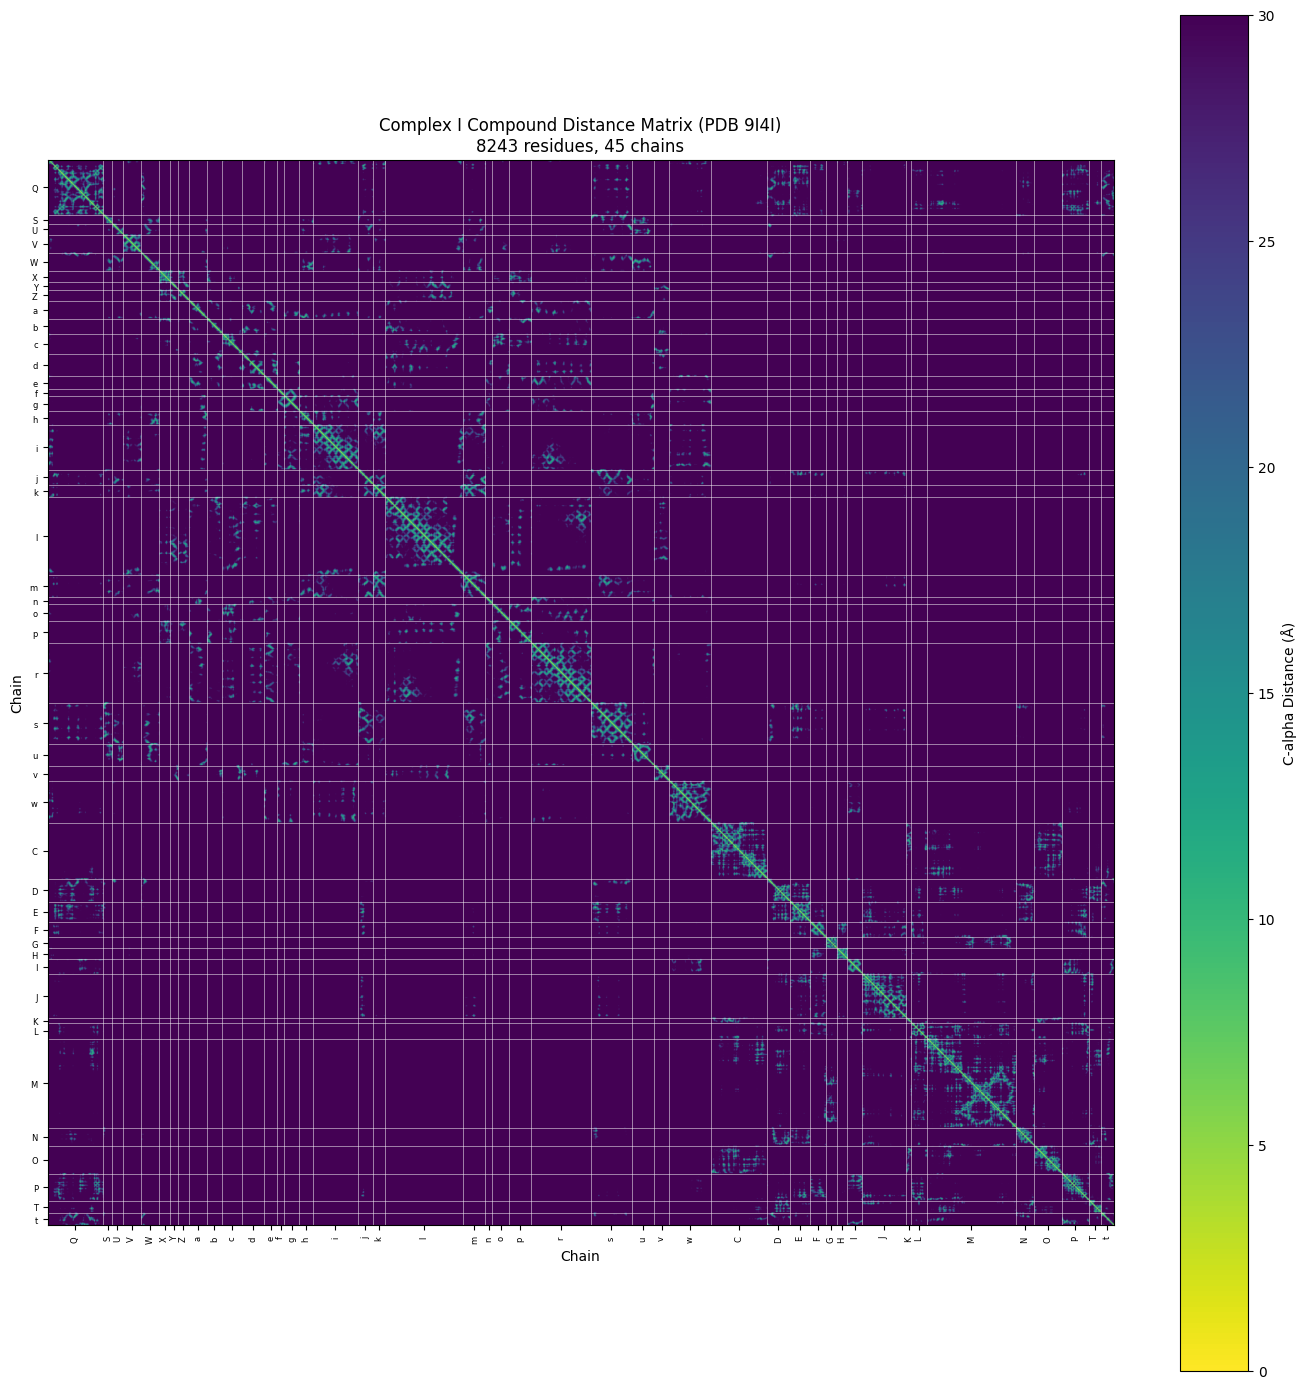

In [8]:
# Visualize compound distance matrix with chain labels
fig, ax = plt.subplots(figsize=(14, 14))
im = ax.imshow(distances, cmap="viridis_r", vmin=0, vmax=30)
# Add chain boundary lines and labels
tick_positions = []
tick_labels_list = []
for label in chain_labels:
    mid = (label["start"] + label["end"]) / 2
    tick_positions.append(mid)
    tick_labels_list.append(label["chain_id"])
    # Draw boundary lines
    ax.axhline(label["start"] - 0.5, color="white", linewidth=0.5, alpha=0.7)
    ax.axvline(label["start"] - 0.5, color="white", linewidth=0.5, alpha=0.7)

# Set custom ticks with chain labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels_list, fontsize=6, rotation=90)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels_list, fontsize=6)
ax.set_xlabel("Chain")
ax.set_ylabel("Chain")
ax.set_title(f"Complex I Compound Distance Matrix (PDB 9I4I)\n{N} residues, {len(chain_labels)} chains")
plt.colorbar(im, ax=ax, label="C-alpha Distance (Å)")
plt.tight_layout()
# plt.savefig("complex1_compound_distances.png", dpi=200, bbox_inches="tight")
plt.show()

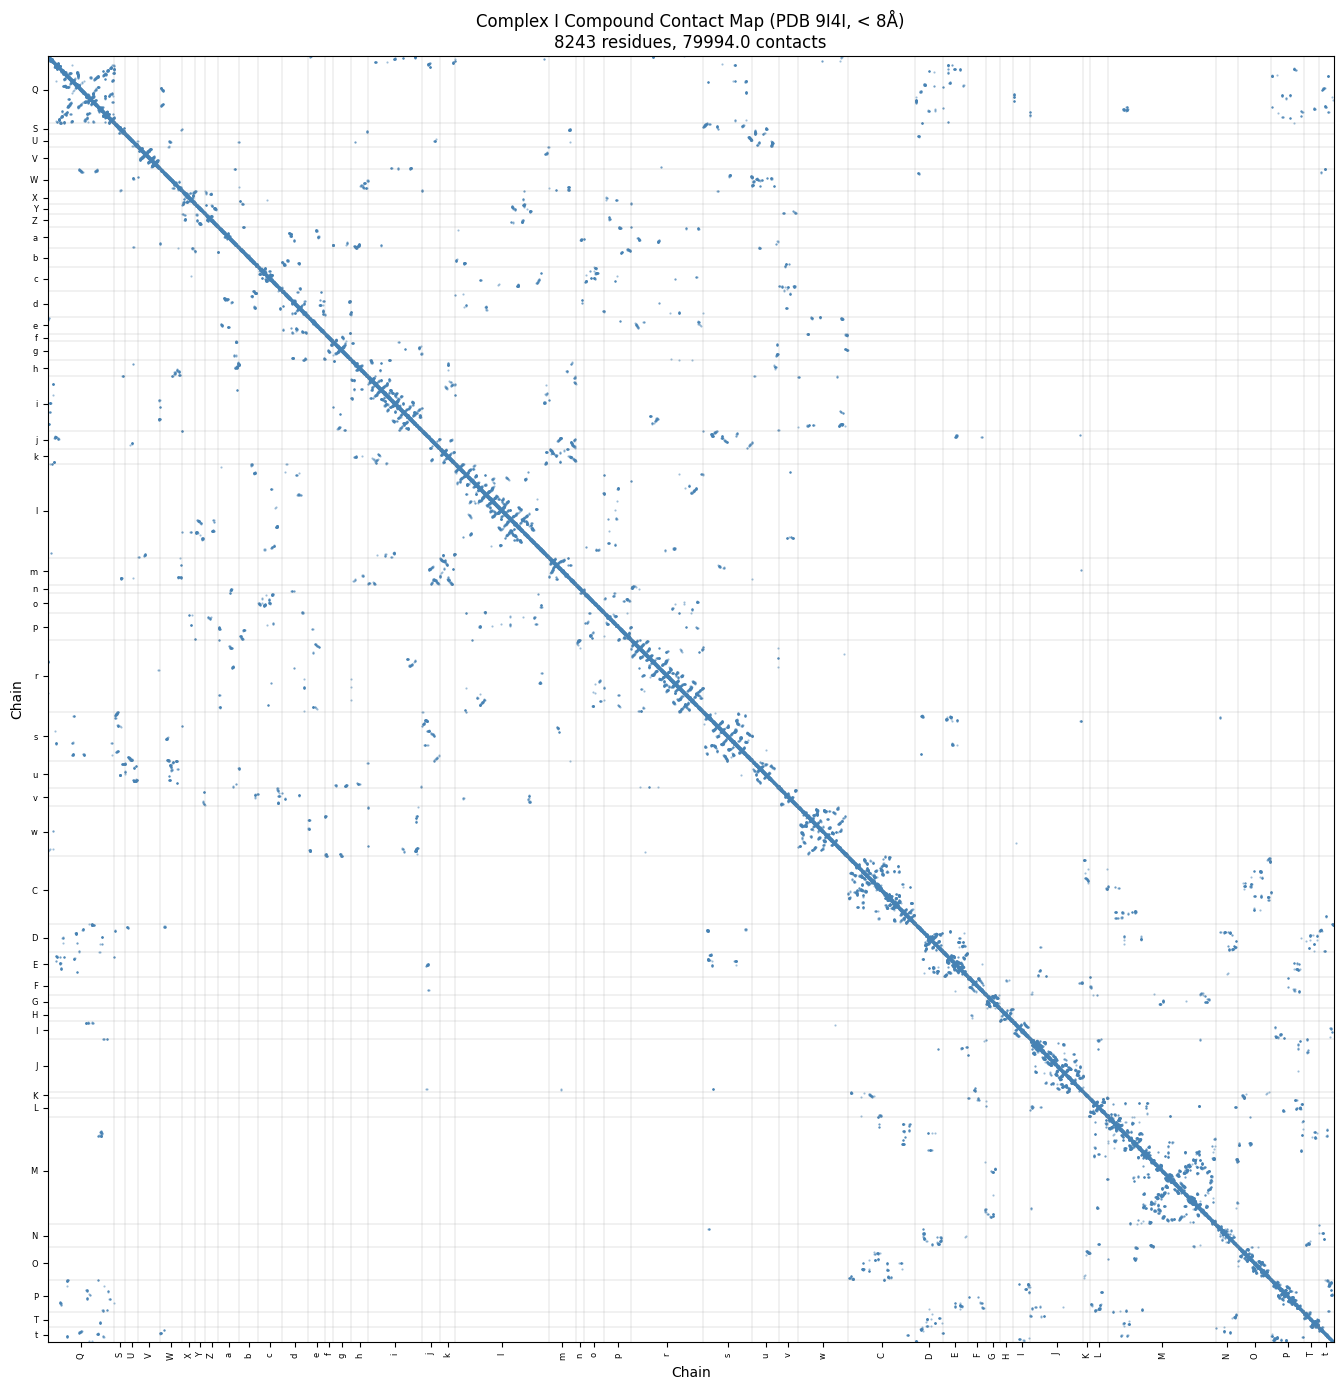

In [9]:
# Visualize compound contact map (binary) with chain labels
fig, ax = plt.subplots(figsize=(14, 14))
contact_i, contact_j = np.where(np.triu(contacts, k=1))
ax.scatter(contact_i, contact_j, c="steelblue", s=0.3, alpha=0.5)
ax.scatter(contact_j, contact_i, c="steelblue", s=0.3, alpha=0.5)
ax.set_xlim(-0.5, N - 0.5)
ax.set_ylim(N - 0.5, -0.5)
ax.set_aspect("equal")
# Add chain boundary lines and labels
tick_positions = []
tick_labels_list = []

for label in chain_labels:
    mid = (label["start"] + label["end"]) / 2
    tick_positions.append(mid)
    tick_labels_list.append(label["chain_id"])
    
    # Draw boundary lines
    ax.axhline(label["start"] - 0.5, color="gray", linewidth=0.3, alpha=0.5)
    ax.axvline(label["start"] - 0.5, color="gray", linewidth=0.3, alpha=0.5)

# Set custom ticks with chain labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels_list, fontsize=6, rotation=90)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels_list, fontsize=6)
ax.set_xlabel("Chain")
ax.set_ylabel("Chain")
ax.set_title(f"Complex I Compound Contact Map (PDB 9I4I, < 8Å)\n{N} residues, {n_contacts} contacts")
plt.tight_layout()
# plt.savefig("complex1_compound_contacts.png", dpi=200, bbox_inches="tight")
plt.show()

In [10]:
# Chain-level summary
gene_names = [l["gene"] for l in chain_labels]
origins = [l["origin"] for l in chain_labels]

In [11]:
# # Save compound contact map
# np.savez(
#     "9I4I_compound_contacts.npz",
#     contacts=contacts,
#     distances=distances,
#     chain_boundaries=np.array(chain_boundaries),
#     gene_names=gene_names,
#     origins=origins,
# )

# Downweight

In [12]:
# Separate chains by genome origin
mtdna_chains = [k for k, v in SUBUNITS.items() if v["origin"] == "mtDNA" and k in chains]
nuclear_chains = [k for k, v in SUBUNITS.items() if v["origin"] == "nuclear" and k in chains]

In [13]:
# Extract inter-chain contacts for all relevant pairs from existing contact map
# 1. Intra-mito: mtDNA × mtDNA (for intra-mito coevolution)
# 2. Mito-nuclear: mtDNA × nuclear (for inter-genome coevolution)

# Build chain index lookup from chain_labels
chain_idx = {label["chain_id"]: label for label in chain_labels}

def extract_pair_contacts(chain1, chain2):
    """Extract contact submatrix for a chain pair from compound contact map.
    
    Returns contact matrix, distances, and total contact count.
    """
    info1 = chain_idx[chain1]
    info2 = chain_idx[chain2]
    contacts_pair = contacts[info1["start"]:info1["end"], info2["start"]:info2["end"]]
    distances_pair = distances[info1["start"]:info1["end"], info2["start"]:info2["end"]]
    return {
        "chain1": chain1,
        "chain2": chain2,
        "gene1": SUBUNITS[chain1]["gene"],
        "gene2": SUBUNITS[chain2]["gene"],
        "origin1": SUBUNITS[chain1]["origin"],
        "origin2": SUBUNITS[chain2]["origin"],
        "len1": info1["length"],
        "len2": info2["length"],
        "contacts": contacts_pair,
        "distances": distances_pair,
        "n_contacts": int(contacts_pair.sum()),
    }

# --- Intra-mito pairs (mtDNA × mtDNA) ---
# Use combinations for unique pairs - contact matrix is symmetric so (A,B) == (B,A)
intra_mito_pairs = []
for c1, c2 in combinations(mtdna_chains, 2):
    intra_mito_pairs.append(extract_pair_contacts(c1, c2))
print(f"Intra-mito pairs: {len(intra_mito_pairs)} (7 C 2 = 21 unique)")
print(f"\n{'Gene1':<10} {'Gene2':<10} {'Contacts':>10}")
print("-" * 32)
for pair in sorted(intra_mito_pairs, key=lambda x: -x["n_contacts"]):
    print(f"{pair['gene1']:<10} {pair['gene2']:<10} {pair['n_contacts']:>10}")

# --- Mito-nuclear pairs (mtDNA × nuclear) ---
# Use product here - these are asymmetric categories (not same-type pairs)
mito_nuclear_pairs = []
for mt_chain, nuc_chain in product(mtdna_chains, nuclear_chains):
    mito_nuclear_pairs.append(extract_pair_contacts(mt_chain, nuc_chain))
print(f"\n\nMito-nuclear pairs: {len(mito_nuclear_pairs)} (7 × 38 = 266)")
print(f"\nTop 15 interacting mito-nuclear pairs:\n")
print(f"{'mtDNA':<10} {'Nuclear':<12} {'Contacts':>10}")
print("-" * 34)
for pair in sorted(mito_nuclear_pairs, key=lambda x: -x["n_contacts"])[:15]:
    print(f"{pair['gene1']:<10} {pair['gene2']:<12} {pair['n_contacts']:>10}")

Intra-mito pairs: 21 (7 C 2 = 21 unique)

Gene1      Gene2        Contacts
--------------------------------
MT-ND4L    MT-ND6            109
MT-ND3     MT-ND1            101
MT-ND3     MT-ND6             80
MT-ND5     MT-ND4             65
MT-ND2     MT-ND4             33
MT-ND2     MT-ND4L            31
MT-ND4L    MT-ND5             28
MT-ND2     MT-ND5             26
MT-ND2     MT-ND6             17
MT-ND6     MT-ND1             17
MT-ND3     MT-ND4L            12
MT-ND2     MT-ND3              0
MT-ND2     MT-ND1              0
MT-ND3     MT-ND5              0
MT-ND3     MT-ND4              0
MT-ND4L    MT-ND4              0
MT-ND4L    MT-ND1              0
MT-ND5     MT-ND6              0
MT-ND5     MT-ND1              0
MT-ND6     MT-ND4              0
MT-ND4     MT-ND1              0


Mito-nuclear pairs: 266 (7 × 38 = 266)

Top 15 interacting mito-nuclear pairs:

mtDNA      Nuclear        Contacts
----------------------------------
MT-ND2     NDUFA10              78
MT-ND1     N

In [14]:
# 3-letter to 1-letter amino acid mapping
AA3_TO_1 = {
    "ALA": "A", "CYS": "C", "ASP": "D", "GLU": "E", "PHE": "F",
    "GLY": "G", "HIS": "H", "ILE": "I", "LYS": "K", "LEU": "L",
    "MET": "M", "ASN": "N", "PRO": "P", "GLN": "Q", "ARG": "R",
    "SER": "S", "THR": "T", "VAL": "V", "TRP": "W", "TYR": "Y",
}

# Aggregate contacts_per_res for each mtDNA subunit directly from compound contact matrix
# Components: intra-chain + inter-mt-mt + inter-mt-nuc

mito_contact_summary = {}
for mt_chain in mtdna_chains:
    subunit_info = SUBUNITS[mt_chain]
    gene = subunit_info["gene"]
    info = chain_idx[mt_chain]
    start, end = info["start"], info["end"]
    length = info["length"]
    residues = chains[mt_chain]["residues"]  # original sequence indices
    res_names_3letter = chains[mt_chain]["res_names"]  # amino acid 3-letter codes from CIF
    res_names = [AA3_TO_1.get(aa, "X") for aa in res_names_3letter]  # convert to 1-letter

    # 1. Intra-chain contacts (diagonal block)
    intra_block = contacts[start:end, start:end]
    intra_per_res = intra_block.sum(axis=1) / 2

    # 2. Inter mtDNA-mtDNA contacts (with OTHER mtDNA chains)
    inter_mt_per_res = np.zeros(length)
    for other_chain in mtdna_chains:
        if other_chain == mt_chain:
            continue
        other_info = chain_idx[other_chain]
        inter_mt_per_res += contacts[start:end, other_info["start"]:other_info["end"]].sum(axis=1)

    # 3. Inter mtDNA-nuclear contacts (with all nuclear chains)
    inter_nuc_per_res = np.zeros(length)
    for nuc_chain in nuclear_chains:
        nuc_info = chain_idx[nuc_chain]
        inter_nuc_per_res += contacts[start:end, nuc_info["start"]:nuc_info["end"]].sum(axis=1)

    # Total contacts per residue
    total_contacts_per_res = intra_per_res + inter_mt_per_res + inter_nuc_per_res

    # Compute downweight: 1 / (total), default 1.0 for no contacts
    downweight = np.where(total_contacts_per_res > 0, 1.0 / total_contacts_per_res, 1.0)

    mito_contact_summary[mt_chain] = {
        "gene": gene,
        "uniprot_accession": subunit_info["uniprot_accession"],
        "uniprot_entry": subunit_info["uniprot_entry"],
        "length": length,
        "residues": residues,
        "res_names": res_names,  # 1-letter amino acid codes
        "intra_per_res": intra_per_res,
        "inter_mt_per_res": inter_mt_per_res,
        "inter_nuc_per_res": inter_nuc_per_res,
        "contacts_per_res": total_contacts_per_res,
        "downweight": downweight,
        "total_contacts": int(total_contacts_per_res.sum()),
    }

# Summary
print("Aggregated mtDNA subunit contact summary:\n")
print(f"{'Gene':<10} {'UniProt':>10} {'Length':>6} {'Res Range':>12} {'Intra':>8} {'Mt-Mt':>8} {'Mt-Nuc':>8} {'Total':>8} {'Mean DW':>10}")
print("-" * 98)
for chain_id, data in mito_contact_summary.items():
    res_range = f"{min(data['residues'])}-{max(data['residues'])}"
    intra_total = int(data["intra_per_res"].sum())
    inter_mt_total = int(data["inter_mt_per_res"].sum())
    inter_nuc_total = int(data["inter_nuc_per_res"].sum())
    mean_dw = data["downweight"].mean()
    seq_preview = "".join(data["res_names"][:10]) + "..."
    print(f"{data['gene']:<10} {data['uniprot_accession']:>10} {data['length']:>6} {res_range:>12} {intra_total:>8} {inter_mt_total:>8} {inter_nuc_total:>8} {data['total_contacts']:>8} {mean_dw:>10.3f}  {seq_preview}")

Aggregated mtDNA subunit contact summary:

Gene          UniProt Length    Res Range    Intra    Mt-Mt   Mt-Nuc    Total    Mean DW
--------------------------------------------------------------------------------------------------
MT-ND2         P03891    347        1-347     1689      107      219     2015      0.183  MNPLAQPVIY...
MT-ND3         P03897    115        1-115      404      193       65      662      0.196  MNFALILMIN...
MT-ND4L        P03901     98         1-98      410      180       32      622      0.167  MPLIYMNIML...
MT-ND5         P03915    601        3-603     2920      119      317     3356      0.192  MHTTMTTLTL...
MT-ND6         P03923    173        1-173      722      223       59     1004      0.192  MMYALFLLSV...
MT-ND4         P03905    459        1-459     2262       98      206     2566      0.190  MLKLIVPTIM...
MT-ND1         P03886    316        3-318     1512      118      309     1939      0.175  MANLLLLIVP...


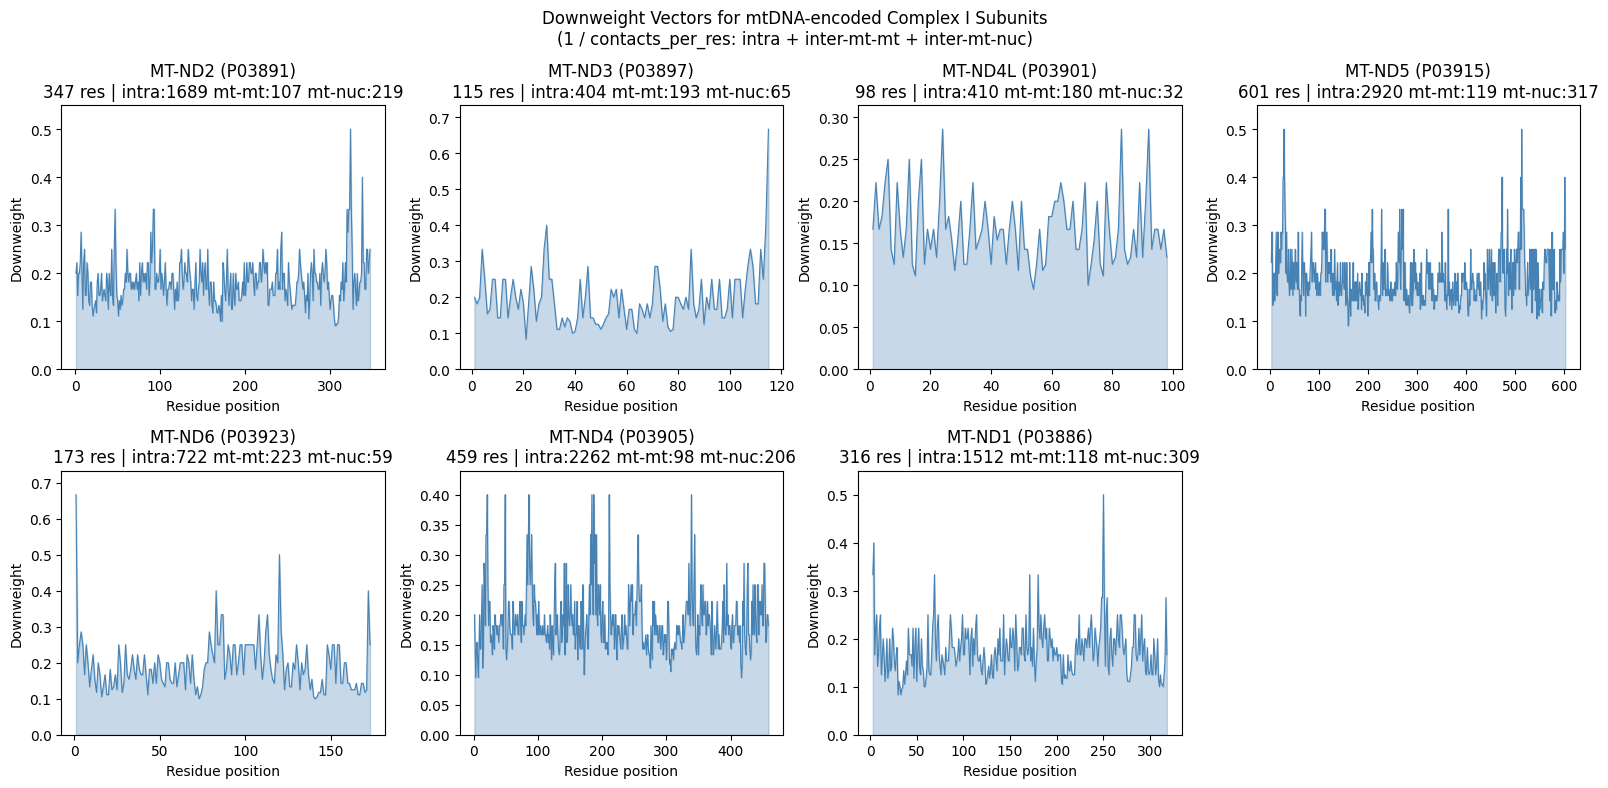

In [15]:
# Plot downweight vectors for each mtDNA subunit
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (chain_id, data) in enumerate(mito_contact_summary.items()):
    ax = axes[idx]
    
    residues = data["residues"]
    downweight = data["downweight"]
    
    ax.plot(residues, downweight, linewidth=0.8, color="steelblue")
    ax.fill_between(residues, downweight, alpha=0.3, color="steelblue")
    
    ax.set_xlabel("Residue position")
    ax.set_ylabel("Downweight")
    intra = int(data["intra_per_res"].sum())
    mt_mt = int(data["inter_mt_per_res"].sum())
    mt_nuc = int(data["inter_nuc_per_res"].sum())
    ax.set_title(f"{data['gene']} ({data['uniprot_accession']})\n{data['length']} res | intra:{intra} mt-mt:{mt_mt} mt-nuc:{mt_nuc}")
    ax.set_ylim(0, max(downweight) * 1.1 if max(downweight) > 0 else 1.1)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.5, alpha=0.7)

# Hide the 8th subplot (we only have 7 mtDNA subunits)
axes[7].axis("off")

plt.suptitle("Downweight Vectors for mtDNA-encoded Complex I Subunits\n(1 / contacts_per_res: intra + inter-mt-mt + inter-mt-nuc)", fontsize=12)
plt.tight_layout()
# plt.savefig("mito_downweight_vectors.png", dpi=150, bbox_inches="tight")
plt.show()

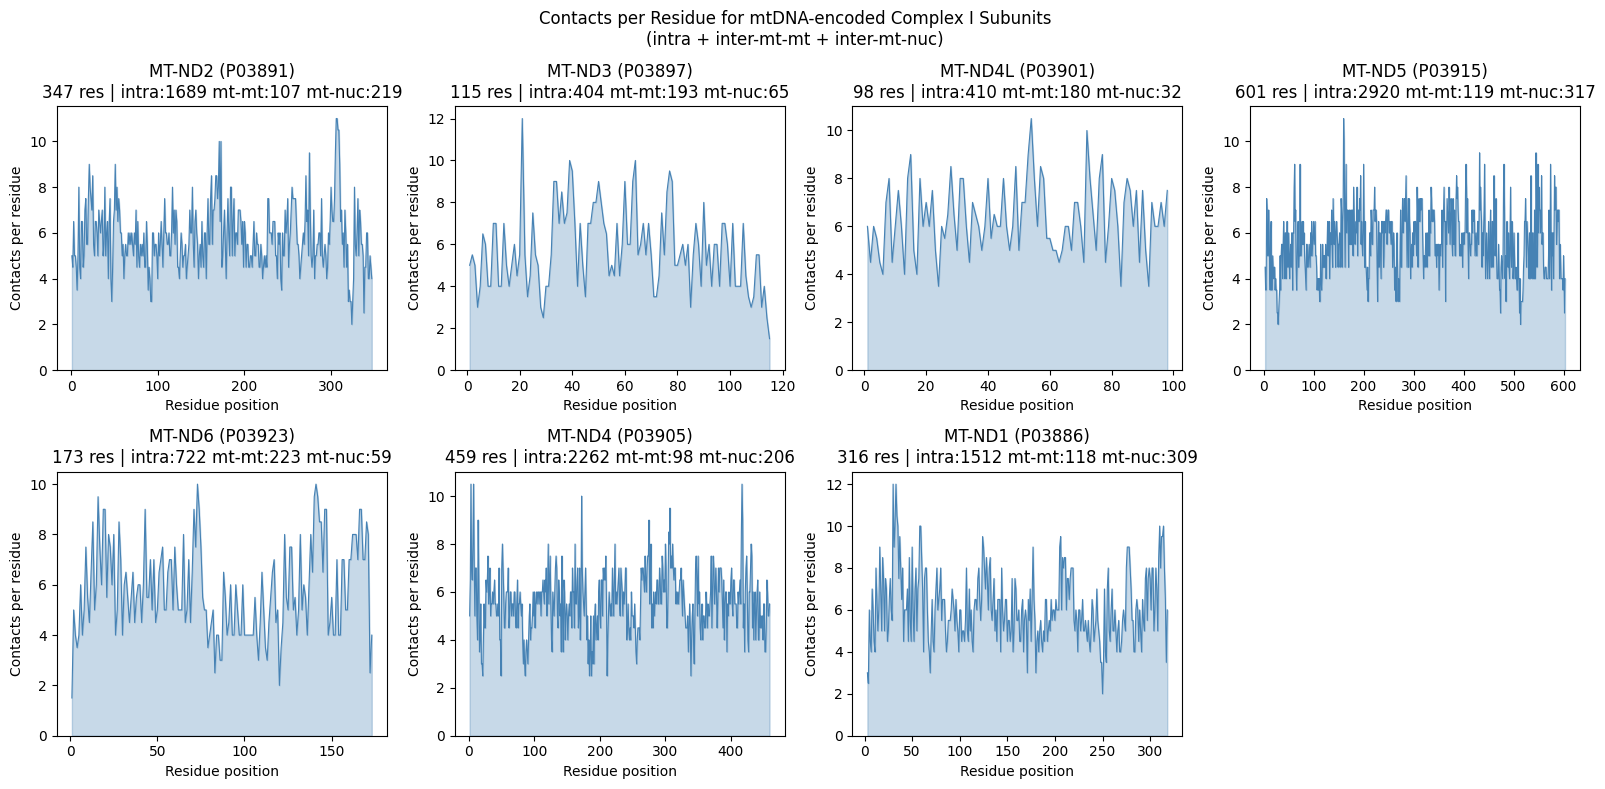

In [16]:
# Plot contacts_per_res for each mtDNA subunit
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (chain_id, data) in enumerate(mito_contact_summary.items()):
    ax = axes[idx]
    
    residues = data["residues"]
    contacts_per_res = data["contacts_per_res"]
    
    ax.plot(residues, contacts_per_res, linewidth=0.8, color="steelblue")
    ax.fill_between(residues, contacts_per_res, alpha=0.3, color="steelblue")
    
    ax.set_xlabel("Residue position")
    ax.set_ylabel("Contacts per residue")
    intra = int(data["intra_per_res"].sum())
    mt_mt = int(data["inter_mt_per_res"].sum())
    mt_nuc = int(data["inter_nuc_per_res"].sum())
    ax.set_title(f"{data['gene']} ({data['uniprot_accession']})\n{data['length']} res | intra:{intra} mt-mt:{mt_mt} mt-nuc:{mt_nuc}")
    ax.set_ylim(0, None)

# Hide the 8th subplot
axes[7].axis("off")

plt.suptitle("Contacts per Residue for mtDNA-encoded Complex I Subunits\n(intra + inter-mt-mt + inter-mt-nuc)", fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
# Save mito_contact_summary to file for downstream analysis
save_dict = {}
for chain_id, data in mito_contact_summary.items():
    gene = data["gene"]
    save_dict[f"{gene}_residues"] = np.array(data["residues"])
    save_dict[f"{gene}_res_names"] = np.array(data["res_names"])  # 1-letter amino acid codes
    save_dict[f"{gene}_intra_per_res"] = data["intra_per_res"]
    save_dict[f"{gene}_inter_mt_per_res"] = data["inter_mt_per_res"]
    save_dict[f"{gene}_inter_nuc_per_res"] = data["inter_nuc_per_res"]
    save_dict[f"{gene}_contacts_per_res"] = data["contacts_per_res"]
    save_dict[f"{gene}_downweight"] = data["downweight"]

np.savez("data/mito_contact_summary.npz", **save_dict)
print(f"Saved mito_contact_summary.npz with {len(save_dict)} arrays:")
for k, v in save_dict.items():
    if "res_names" in k:
        print(f"  {k}: {v.shape} {v.dtype} -> {''.join(v[:5])}...")
    else:
        print(f"  {k}: {v.shape} {v.dtype}")

Saved mito_contact_summary.npz with 49 arrays:
  MT-ND2_residues: (347,) int64
  MT-ND2_res_names: (347,) <U1 -> MNPLA...
  MT-ND2_intra_per_res: (347,) float64
  MT-ND2_inter_mt_per_res: (347,) float64
  MT-ND2_inter_nuc_per_res: (347,) float64
  MT-ND2_contacts_per_res: (347,) float64
  MT-ND2_downweight: (347,) float64
  MT-ND3_residues: (115,) int64
  MT-ND3_res_names: (115,) <U1 -> MNFAL...
  MT-ND3_intra_per_res: (115,) float64
  MT-ND3_inter_mt_per_res: (115,) float64
  MT-ND3_inter_nuc_per_res: (115,) float64
  MT-ND3_contacts_per_res: (115,) float64
  MT-ND3_downweight: (115,) float64
  MT-ND4L_residues: (98,) int64
  MT-ND4L_res_names: (98,) <U1 -> MPLIY...
  MT-ND4L_intra_per_res: (98,) float64
  MT-ND4L_inter_mt_per_res: (98,) float64
  MT-ND4L_inter_nuc_per_res: (98,) float64
  MT-ND4L_contacts_per_res: (98,) float64
  MT-ND4L_downweight: (98,) float64
  MT-ND5_residues: (601,) int64
  MT-ND5_res_names: (601,) <U1 -> MHTTM...
  MT-ND5_intra_per_res: (601,) float64
  MT-ND5